In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

conn = sqlite3.connect(r"sqlRSuperStore.db")

## Question 6: Sales, Region

In [4]:
query = '''
SELECT "Discount", AVG("Profit") AS avg_profit, AVG("Sales") AS avg_sales
FROM "Sample - Superstore"
GROUP BY "Discount"
ORDER BY "Discount" ASC;
'''

impact = pd.read_sql_query(query, conn)
print(impact)

    Discount  avg_profit   avg_sales
0       0.00   66.900292  226.742074
1       0.10   96.055074  578.397351
2       0.15   27.288298  529.971567
3       0.20   24.702572  209.076940
4       0.30  -45.679636  454.742974
5       0.32  -88.560656  536.794770
6       0.40 -111.927429  565.134874
7       0.45 -226.646464  498.634000
8       0.50 -310.703456  892.705152
9       0.60  -43.077212   48.150000
10      0.70  -95.874060   97.177708
11      0.80 -101.796797   56.545853


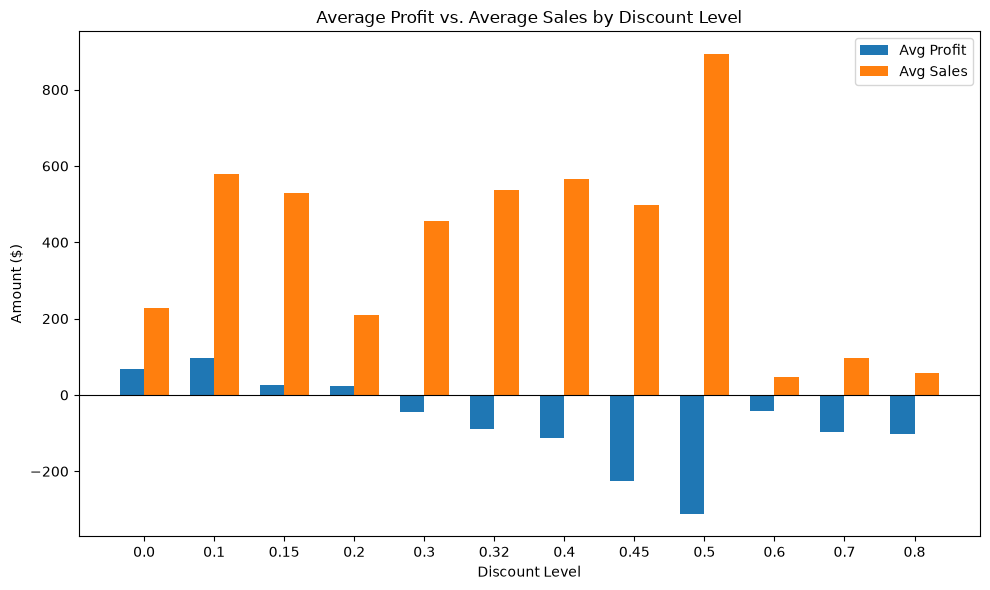

In [3]:
x = np.arange(len(impact))  # positions for each discount level
width = 0.35  # width of each bar

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, impact["avg_profit"], width, label="Avg Profit")
ax.bar(x + width/2, impact["avg_sales"], width, label="Avg Sales")

ax.set_xlabel("Discount Level")
ax.set_ylabel("Amount ($)")
ax.set_title("Average Profit vs. Average Sales by Discount Level")
ax.set_xticks(x)
ax.set_xticklabels(impact["Discount"].astype(str))
ax.legend()
ax.axhline(0, color="black", linewidth=0.8)  # zero line — important since profit can go negative

plt.tight_layout()
plt.savefig("profit_vs_sales_by_discount.png")
plt.show()

# Takeaway: